In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load the cleaned dataset
data = pd.read_csv('data/clean/cleaned_data.csv')

# Display the first few rows of the dataset to verify it loaded correctly
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,1,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
1,49,0,2,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
2,37,1,1,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
3,33,0,2,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
4,27,0,1,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [8]:
# Checking the target column for imbalance between classes

class_imbalance = data['Attrition'].mean().round(3) * 100
print(f"Class imbalance (percentage of positive class): {class_imbalance}%")

Class imbalance (percentage of positive class): 16.1%


# Class Imbalance

##### Due to the imbalance between classes, accuracy would not be a reliable metric for evaluating how well the model predicts whether employees will leave or stay. 

### ROC-AUC 
##### This will be a better primary metric because it measures how well the model can distinguish between employees who leave and employees who stay across different classification thresholds.

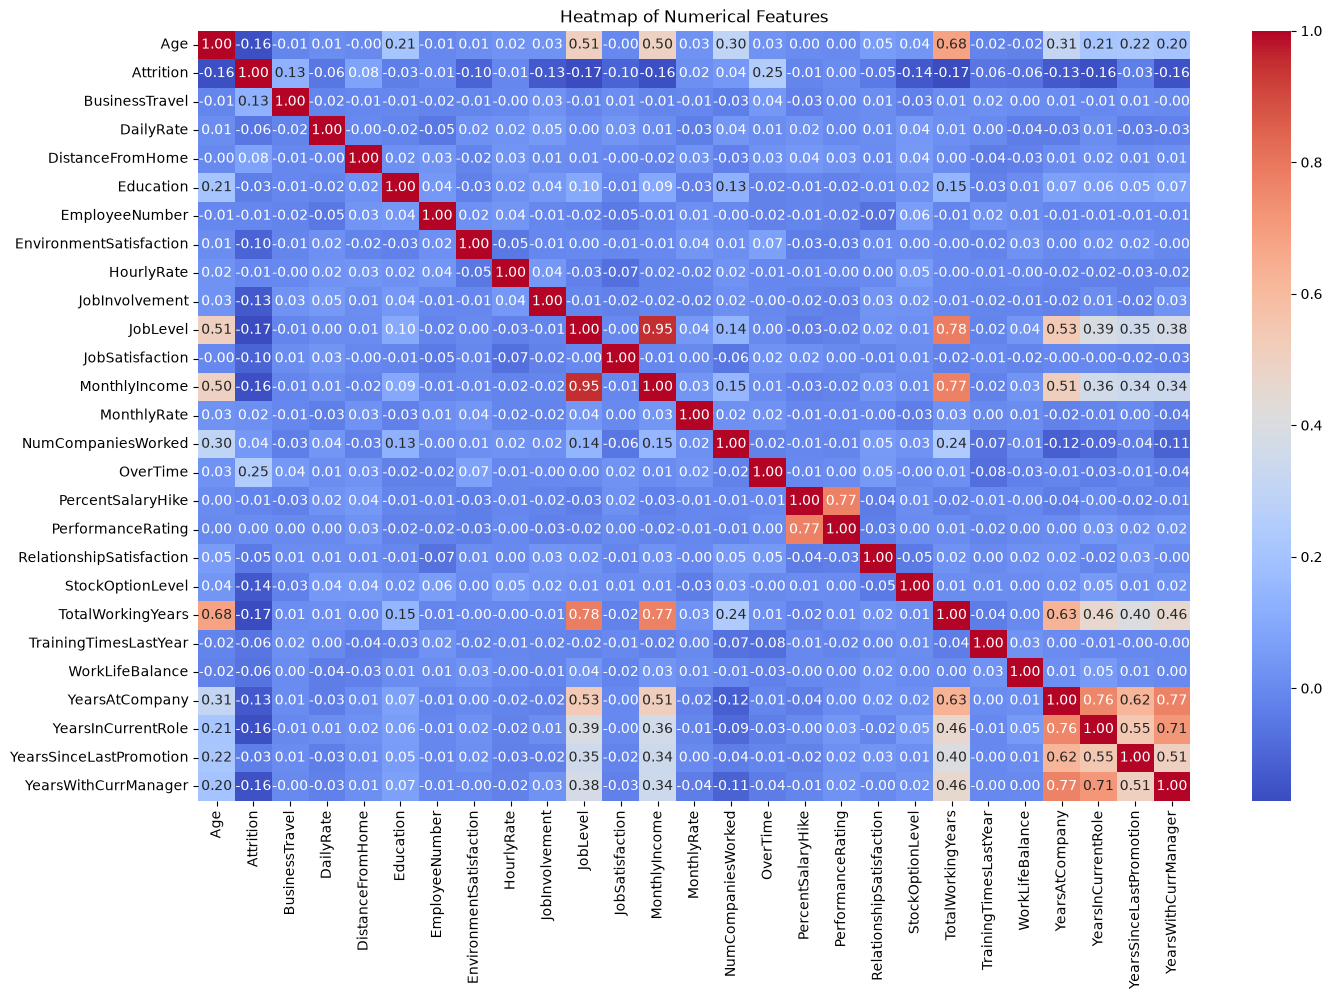

In [15]:
# Visualizing the correlation between numerical features using a heatmap

numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(16, 10))
sns.heatmap(data[numerical_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap of Numerical Features")
plt.show()

# Heatmap Findings

##### Looking at this heatmap above we are inspecting columns with correlation that is greater than .8 to prevent Multi-Colllinearity. 

## Monthly vs. Job Level

##### Monthly Income and Job Level have a very strong positive correlation of approximately 0.95, indicating that employees at higher job levels generally have higher monthly incomes. Because both variables are included in the project hypothesis, they will initially be retained for the statistical analysis. However, their strong correlation indicates potential multicollinearity and will need to be considered when interpreting the logistic regression results.


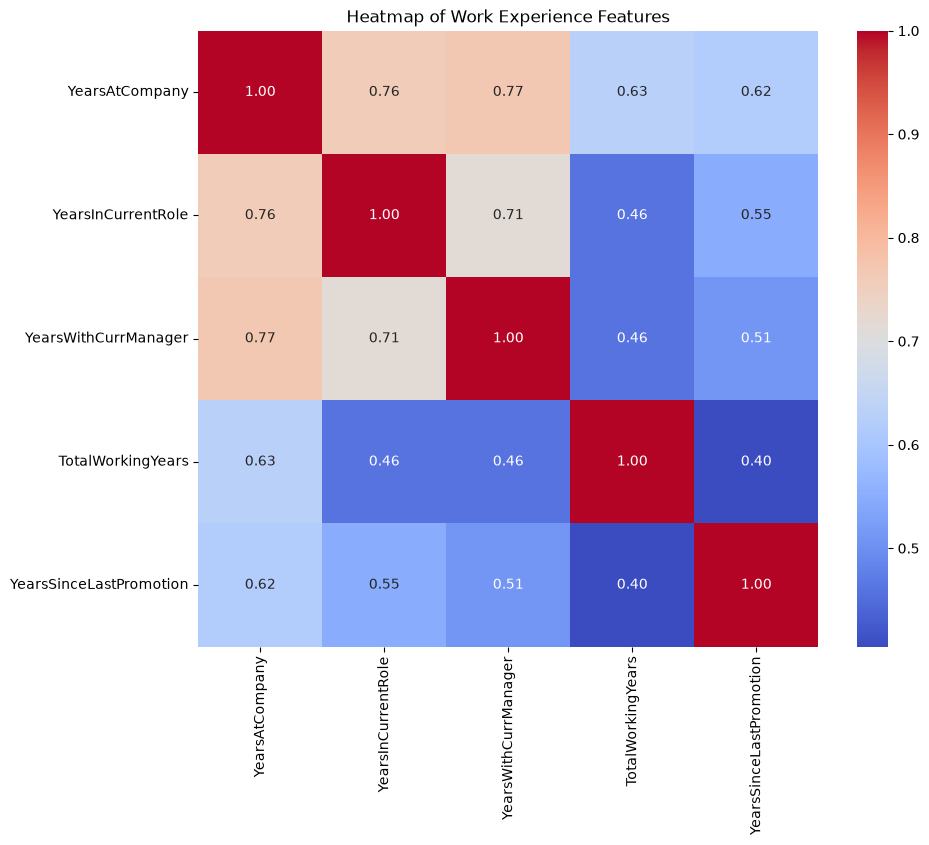

In [17]:
highly_correlated_work_experience = data[['YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager', 'TotalWorkingYears', 'YearsSinceLastPromotion']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(highly_correlated_work_experience, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap of Work Experience Features")
plt.show()